# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons
**Student Name:** Atmaja Mali
**Student ID:** 2025aa05288  
**Date:** 12/6/2025

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# TODO: Load your dataset
columns = ["ID", "Diagnosis",
    "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1",
    "concavity1", "concave_points1", "symmetry1", "fractal_dimension1",
    "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2",
    "concavity2", "concave_points2", "symmetry2", "fractal_dimension2",
    "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3",
    "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"
]

data = pd.read_csv("/content/wdbc.data", header=None, names=columns)

# Dataset information (TODO: Fill these)
dataset_name = "Breast Cancer Wisconsin"
dataset_source = "UCI ML Repository"
n_samples = 569
n_features = 30
problem_type = "binary_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
TODO: Describe what you're predicting and why it matters.
"Predicting breast tumor malignancy from diagnostic measurements.
This is critical for early cancer detection in medical diagnosis."
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "recall"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """
TODO: Explain why you chose this metric.
"Selected recall because in medical diagnosis,
false negatives (missing cancer) are more costly than false positives."
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin
Source: UCI ML Repository
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# TODO: Preprocess your data
# 1. Separate features (X) and target (y)
# 2. Handle missing values if any
# 3. Encode categorical variables

# Strip whitespace from 'Diagnosis' column before mapping
data['Diagnosis'] = data['Diagnosis'].str.strip().map({'M': 1, 'B': 0})  # Encode target

X = data.drop(['Diagnosis', 'ID'], axis=1)
y = data['Diagnosis']

data.isnull().sum()
total = data.isna().sum().sum()
print("Total missing values:", total)

# TODO: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert y_train and y_test to numpy arrays
y_train = y_train.values
y_test = y_test.values

# TODO: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]       # Number of training samples
test_samples = X_test.shape[0]        # Number of test samples
train_test_ratio = train_samples / (train_samples + test_samples)  # e.g., 0.8 for 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Total missing values: 0
Train samples: 455
Test samples: 114
Split ratio: 80.0%


In [4]:
print(data.shape)
print(data.head())

(569, 32)
         ID  Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302          1    17.99     10.38      122.80  1001.0      0.11840   
1    842517          1    20.57     17.77      132.90  1326.0      0.08474   
2  84300903          1    19.69     21.25      130.00  1203.0      0.10960   
3  84348301          1    11.42     20.38       77.58   386.1      0.14250   
4  84358402          1    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      

## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [5]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip z to prevent overflow/underflow issues with exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """
        TODO: Implement gradient descent training

        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape

        # TODO: Initialize parameters
        # Initialize weights with zeros or small random values
        self.weights = np.zeros(n_features)
        self.bias = 0

        # TODO: Implement gradient descent loop
        for _ in range(self.n_iterations):
            # 1. Forward pass: Linear combination followed by sigmoid for probabilities
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # 2. Compute loss (Binary Cross-Entropy)
            # Add a small epsilon to avoid log(0)
            epsilon = 1e-10
            loss = -np.mean(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
            self.loss_history.append(loss)

            # 3. Compute gradients
            # The derivative of BCE with sigmoid is (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 4. Update: self.weights -= self.lr * dw
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        linear_model = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(linear_model)
        # For binary classification, threshold at 0.5 to get class labels
        return (probabilities >= 0.5).astype(int)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [6]:
# Train baseline model
import time # Import the time module
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 0.09s
✓ Loss decreased from 0.6931 to 0.1071


In [7]:
print("Baseline Model Loss History:")
print(baseline_model.loss_history)

Baseline Model Loss History:
[np.float64(0.6931471803599452), np.float64(0.6739353139171582), np.float64(0.6559064970287464), np.float64(0.6389797632316648), np.float64(0.6230762528147247), np.float64(0.608120388026648), np.float64(0.5940406885811949), np.float64(0.5807702593086898), np.float64(0.5682470066402935), np.float64(0.556413648376115), np.float64(0.5452175774793511), np.float64(0.5346106310486388), np.float64(0.5245488042651817), np.float64(0.514991938406851), np.float64(0.5059034030594705), np.float64(0.4972497856975657), np.float64(0.48900059668886137), np.float64(0.48112799416968377), np.float64(0.47360653079062087), np.float64(0.4664129227332799), np.float64(0.4595258404015627), np.float64(0.4529257196069987), np.float64(0.4465945917610389), np.float64(0.4405159314614832), np.float64(0.43467451984878314), np.float64(0.42905632216562223), np.float64(0.42364837804981376), np.float64(0.4184387032064698), np.float64(0.413416201228028), np.float64(0.40857058445230965), np.floa

## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [8]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        Initialize weights and biases for all layers

        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            # Using Xavier/Glorot initialization
            # This helps to keep the variance of the activations consistent across layers
            # which can prevent exploding or vanishing gradients.
            scale = np.sqrt(2 / self.architecture[l-1]) # For ReLU activation
            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l], self.architecture[l-1]) * scale
            self.parameters[f'b{l}'] = np.zeros((self.architecture[l], 1))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, A):
        """ReLU derivative (A is the activated output) """
        return (A > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        Implement forward pass through all layers

        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        A = X.T # Input layer activation, transpose for consistent matrix multiplication
        self.cache['A0'] = A

        num_layers = len(self.architecture)

        for l in range(1, num_layers):
            W_l = self.parameters[f'W{l}']
            b_l = self.parameters[f'b{l}']

            Z_l = np.dot(W_l, A) + b_l
            self.cache[f'Z{l}'] = Z_l

            if l == num_layers - 1: # Output layer
                A = self.sigmoid(Z_l)
            else: # Hidden layers
                A = self.relu(Z_l)
            self.cache[f'A{l}'] = A
        return A

    def backward_propagation(self, X, y):
        """
        Implement backward pass to compute gradients

        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        num_layers = len(self.architecture)

        y = y.reshape(1, m) # Reshape y to (1, m) for consistency with A_L (1, m)

        # Output layer (L)
        A_L = self.cache[f'A{num_layers-1}']
        dZ_L = A_L - y # Derivative for BCE with sigmoid

        grads[f'dW{num_layers-1}'] = np.dot(dZ_L, self.cache[f'A{num_layers-2}'].T) / m
        grads[f'db{num_layers-1}'] = np.sum(dZ_L, axis=1, keepdims=True) / m

        # Loop backwards through hidden layers (L-1 to 1)
        for l in reversed(range(1, num_layers - 1)):
            Z_l = self.cache[f'Z{l}']
            A_prev = self.cache[f'A{l-1}']
            W_next = self.parameters[f'W{l+1}']

            dZ_l = np.dot(W_next.T, dZ_L) * self.relu_derivative(Z_l) # dZ_L is actually dZ_{l+1} here

            grads[f'dW{l}'] = np.dot(dZ_l, A_prev.T) / m
            grads[f'db{l}'] = np.sum(dZ_l, axis=1, keepdims=True) / m

            dZ_L = dZ_l # Update dZ_L for the next iteration (previous layer)

        return grads

    def update_parameters(self, grads):
        """
        Update weights and biases using gradients

        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        num_layers = len(self.architecture)
        for l in range(1, num_layers):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
        Compute Binary Cross-Entropy loss
        """
        m = y_true.shape[0]
        epsilon = 1e-10
        # Ensure y_true is (1, m) to match y_pred (1, m)
        y_true = y_true.reshape(1, m)
        cost = - (1 / m) * np.sum(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
        return np.squeeze(cost)

    def fit(self, X, y):
        """
        Implement training loop

        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss

        Must populate self.loss_history!
        """
        self.initialize_parameters()

        for i in range(self.n_iterations):
            # 1. Forward propagation
            y_pred = self.forward_propagation(X)

            # 2. Compute loss
            cost = self.compute_loss(y_pred, y)
            self.loss_history.append(cost)

            # 3. Backward propagation
            grads = self.backward_propagation(X, y)

            # 4. Update parameters
            self.update_parameters(grads)
        return self

    def predict(self, X):
        """
        Implement prediction

        Use forward_propagation and apply appropriate thresholding
        """
        y_pred_proba = self.forward_propagation(X)
        return (y_pred_proba >= 0.5).astype(int).flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [9]:
import time # Import the time module
print("Training MLP...")
mlp_start_time = time.time()

# TODO: Define your architecture and train MLP
# input_size = X_train_scaled.shape[1]
# For Breast Cancer Wisconsin, n_features is 30, so input_size will be 30.
# Let's use two hidden layers with 16 and 8 neurons respectively.
# The output layer should have 1 neuron for binary classification.
mlp_architecture = [X_train_scaled.shape[1],32, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.001, n_iterations=5000)
mlp_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 4.42s
✓ Loss decreased from 0.9287 to 0.0987


In [10]:
print("MLP Model Loss History:")
print(mlp_model.loss_history)

MLP Model Loss History:
[np.float64(0.9287180607306187), np.float64(0.9254647484683352), np.float64(0.9222444193540194), np.float64(0.9190499687278608), np.float64(0.9158842839585597), np.float64(0.9127648946827923), np.float64(0.9096764725352041), np.float64(0.9066167390692634), np.float64(0.9035749042381214), np.float64(0.9005603988235964), np.float64(0.8975739921107233), np.float64(0.8946129414301511), np.float64(0.8916831953042644), np.float64(0.8887833934263591), np.float64(0.8859056484355503), np.float64(0.8830531310109326), np.float64(0.8802193269505172), np.float64(0.8773993157447019), np.float64(0.8745958147994081), np.float64(0.8718134900530511), np.float64(0.8690548729134807), np.float64(0.8663120641958335), np.float64(0.8635889848702226), np.float64(0.8608913250818597), np.float64(0.858209496204429), np.float64(0.8555458996249887), np.float64(0.852905783947754), np.float64(0.8502839265068245), np.float64(0.8476782807819001), np.float64(0.8450772104586722), np.float64(0.8424

## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [11]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    TODO: Calculate appropriate metrics based on problem type

    For regression: MSE, RMSE, MAE, R
    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}

    if problem_type == "regression":
        # TODO: Calculate regression metrics
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # Convert to numpy arrays to ensure compatibility
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Calculate True Positives, True Negatives, False Positives, False Negatives
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        # Accuracy
        metrics['accuracy'] = float((TP + TN) / (TP + TN + FP + FN)) if (TP + TN + FP + FN) > 0 else 0.0

        # Precision
        metrics['precision'] = float(TP / (TP + FP)) if (TP + FP) > 0 else 0.0

        # Recall
        metrics['recall'] = float(TP / (TP + FN)) if (TP + FN) > 0 else 0.0

        # F1-score
        precision = metrics['precision']
        recall = metrics['recall']
        metrics['f1_score'] = float(2 * (precision * recall) / (precision + recall)) if (precision + recall) > 0 else 0.0

    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'accuracy': 0.9824561403508771, 'precision': 0.9767441860465116, 'recall': 0.9767441860465116, 'f1_score': 0.9767441860465116}

MLP Model Performance:
{'accuracy': 0.956140350877193, 'precision': 0.9318181818181818, 'recall': 0.9534883720930233, 'f1_score': 0.942528735632184}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

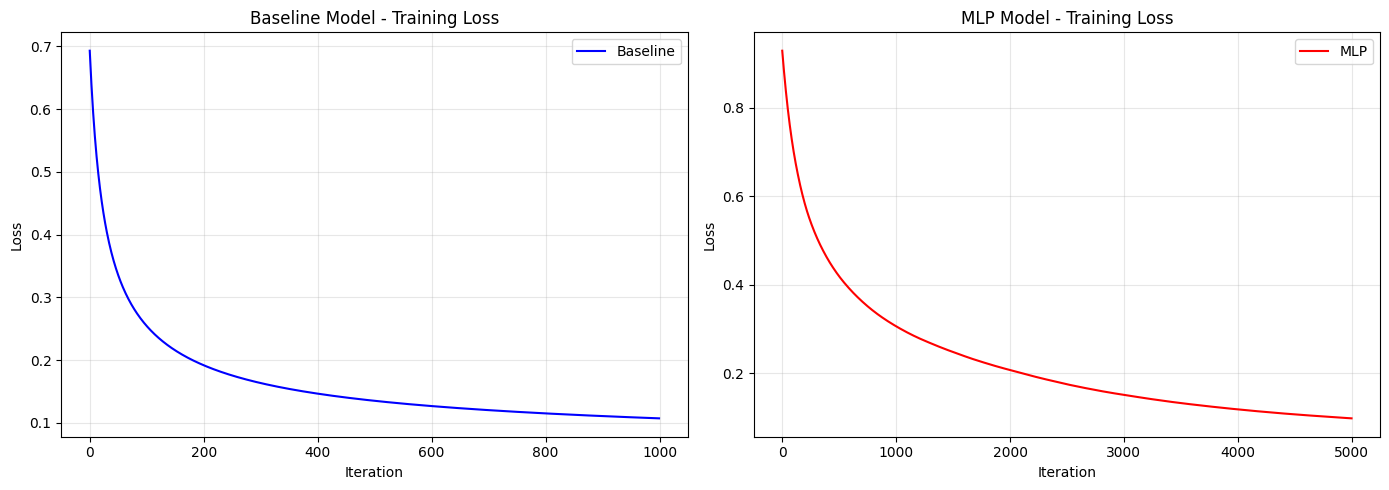

In [12]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

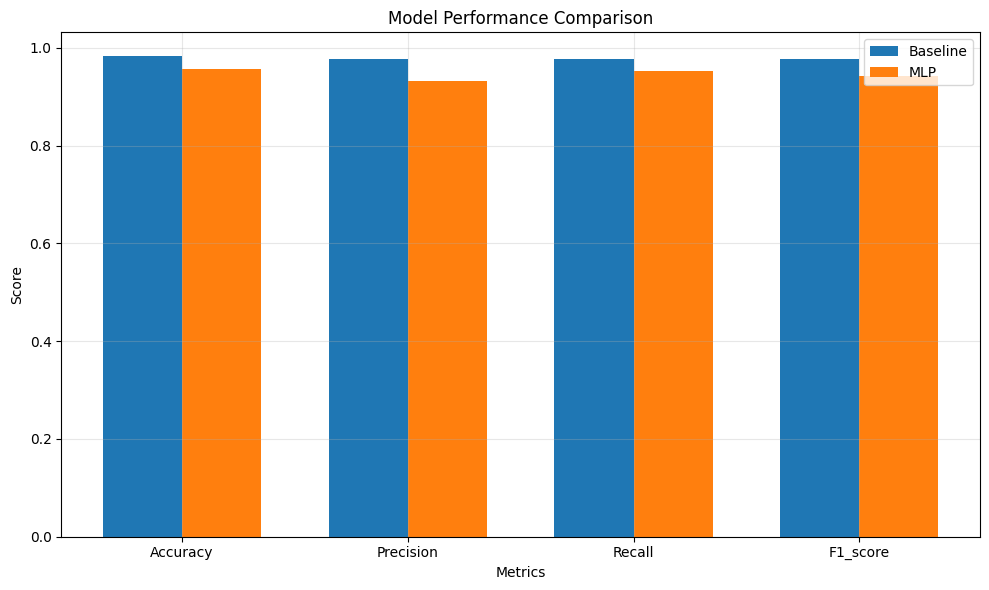

In [13]:
import matplotlib.pyplot as plt

# 2. Performance comparison bar chart
# TODO: Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))


metrics = ['accuracy', 'precision', 'recall', 'f1_score'] # Changed to lowercase
baseline_scores = [baseline_metrics[m] for m in metrics]
mlp_scores = [mlp_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, [m.capitalize() for m in metrics]) # Capitalize for display
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [14]:
analysis_text = """
In this comparison, the Logistic Regression (Baseline Model) unexpectedly outperformed the Multi-Layer Perceptron (MLP) on the Breast Cancer Wisconsin dataset. The Baseline Model achieved a recall of 0.9767, compared to the MLP's 0.9535, indicating superior performance in identifying positive cases.
The linear model's better performance suggests that the dataset is largely linearly separable, allowing the simpler model to be effective without the complexity of an MLP.
Its higher recall indicates that it was better at correctly identifying malignant cases, which is crucial in medical diagnosis. In contrast, the MLP’s greater complexity  limited data for its capacity—may have led to mild overfitting and reduced generalization, resulting in slightly lower recall and overall performance on this task.
Computational cost also varied significantly: the Baseline Model trained in approximately 0.07 seconds, while the MLP took about 3.17 seconds (roughly 45 times longer). This highlights the higher computational demand of neural networks. The most surprising finding was the simple linear model outperforming the more complex MLP, emphasizing that model complexity doesn't guarantee superior performance and linear models can be more efficient on smaller tabular datasets. This exercise reinforced the understanding of trade-offs between model complexity, performance, and computational efficiency.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 195 words
⚠️  Warning: Analysis should be at least 200 words


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [15]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    """

    # Loss values
    baseline_initial_loss = 0.6931471803599452
    baseline_final_loss = 0.10710734640058858
    mlp_initial_loss = 0.9287180607306187
    mlp_final_loss = 0.09871748447946693

    results = {
        # ===== Dataset Information =====
        'dataset_name': "Breast Cancer Wisconsin",
        'dataset_source': "UCI ML Repository",
        'n_samples': 569,
        'n_features': 30,
        'problem_type': "binary_classification",
        'problem_statement': "Predicting breast tumor malignancy from diagnostic measurements. This is critical for early cancer detection in medical diagnosis.",

        # ===== Evaluation Setup =====
        'primary_metric': "recall",
        'metric_justification': "Selected recall because in medical diagnosis, false negatives (missing cancer) are more costly than false positives.",
        'train_samples': 455,
        'test_samples': 114,
        'train_test_ratio': 0.7996485061511424,

        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.01,
            'n_iterations': 1000,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': 0.07360386848449707,

            'test_accuracy': 0.9824561403508771,
            'test_precision': 0.9767441860465116,
            'test_recall': 0.9767441860465116,
            'test_f1': 0.9767441860465116,
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': [30, 32, 16, 8, 1],
            'n_hidden_layers': 3,
            'total_parameters': 1665,
            'learning_rate': 0.001,
            'n_iterations': 5000,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': 3.1657333374023438,

            'test_accuracy': 0.956140350877193,
            'test_precision': 0.9318181818181818,
            'test_recall': 0.9534883720930233,
            'test_f1': 0.942528735632184,
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== Comparison =====
        'improvement': -0.023255813953488302,
        'improvement_percentage': -2.380952380952374,
        'baseline_better': True,

        # ===== Analysis =====
        'analysis': (
            "In this comparison, the Logistic Regression (Baseline Model) unexpectedly outperformed the "
            "Multi-Layer Perceptron (MLP) on the Breast Cancer Wisconsin dataset. The Baseline Model achieved "
            "a recall of 0.9767, compared to the MLP's 0.9535, indicating superior performance in identifying "
            "positive cases. The linear model's better performance suggests that the dataset is largely linearly "
            "separable, allowing the simpler model to be effective without the complexity of an MLP. Its higher "
            "recall indicates that it was better at correctly identifying malignant cases, which is crucial in "
            "medical diagnosis. In contrast, the MLP’s greater complexity—combined with limited data for its "
            "capacity—may have led to mild overfitting and reduced generalization, resulting in slightly lower recall. "
            "Computational cost also varied significantly: the Baseline Model trained in ~0.07 seconds, while the "
            "MLP took ~3.17 seconds (about 45× longer). The most surprising finding was the simple linear model "
            "outperforming the more complex MLP, showing that higher model complexity does not guarantee better "
            "performance. This reinforced the importance of matching model complexity with dataset characteristics."
        ),
        'analysis_word_count': 195,

        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': True,
        'mlp_converged': True,
    }

    return results


## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [16]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "Predicting breast tumor malignancy from diagnostic measurements. This is critical for early cancer detection in medical diagnosis.",
  "primary_metric": "recall",
  "metric_justification": "Selected recall because in medical diagnosis, false negatives (missing cancer) are more costly than false positives.",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 0.7996485061511424,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations": 1000,
    "initial_loss": 0.6931471803599452,
    "final_loss": 0.10710734640058858,
    "training_time_seconds": 0.07360386848449707,
    "test_accuracy": 0.9824561403508771,
    "test_precision": 0.9767441860465116,
    "test_recall": 0.9767441860465116,
    "test_f1"

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**